In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from loguru import logger
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

Let's load the parquetfile we saved in notebook 1. You will need to change the filename in the config file!

In [68]:
import tomllib

configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)
config

{'raw': 'data/raw',
 'processed': 'data/processed',
 'input': '_chat.txt',
 'current': 'whatsapp-20250318-185053.parq',
 'inputpath': 'whatsapp-20250318-185053.csv',
 'datetime_format': '%d-%m-%Y, %H:%M:%S',
 'pseudoname': 'laughing-cat'}

In [69]:
root = Path("..").resolve()
processed = root / Path(config["processed"])
datafile = processed / config["current"]
if not datafile.exists():
    logger.warning(
        f"{datafile} does not exist. First run src/preprocess.py, and check the timestamp!"
    )

Note how datatypes have been preserved.

In [70]:
df = pd.read_parquet(datafile)
df.dtypes

timestamp             datetime64[ns]
message                       object
author                        object
has_emoji                       bool
is_topk                         bool
message_length                 int64
has_link                        bool
timestamp_category          category
hour                          object
day_of_week                    int32
dtype: object

In [71]:
df.head()

,timestamp,message,author,has_emoji,is_topk,message_length,has_link,timestamp_category,hour,day_of_week
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,False,True,39,False,worktimes,10:14:17,5
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,False,True,41,False,evening,19:50:13,2
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,False,True,29,False,evening,19:59:39,2
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,False,True,18,False,evening,20:00:35,2
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,True,True,21,False,evening,20:07:02,2


Let's count the amount of messages, per author.

In [72]:
p1 = (
    df[["author", "message"]]
    .groupby("author")
    .count()
    .sort_values("message", ascending=False)
)

k = 15
topk = p1[:k]

In [73]:
topk_authors = list(topk.index)

In [74]:
df["is_topk"] = df["author"].apply(lambda x: x in topk_authors)
df.head()

,timestamp,message,author,has_emoji,is_topk,message_length,has_link,timestamp_category,hour,day_of_week
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,False,True,39,False,worktimes,10:14:17,5
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,False,True,41,False,evening,19:50:13,2
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,False,True,29,False,evening,19:59:39,2
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,False,True,18,False,evening,20:00:35,2
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,True,True,21,False,evening,20:07:02,2


Text(0.5, 1.0, 'Sending the most messages...')

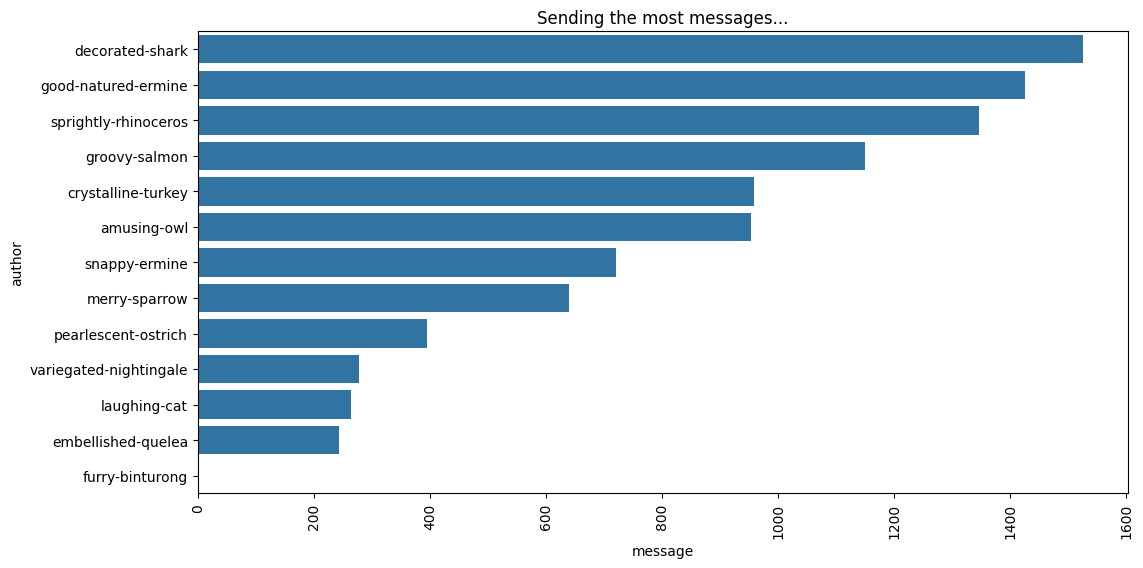

In [75]:
plt.figure(figsize=(12, 6))
sns.barplot(y=p1.index[:k], x="message", data=topk)
plt.xticks(rotation=90)
plt.title("Sending the most messages...")

Maybe tweak the colors a bit

Text(0.5, 1.0, 'Sending the most messages...')

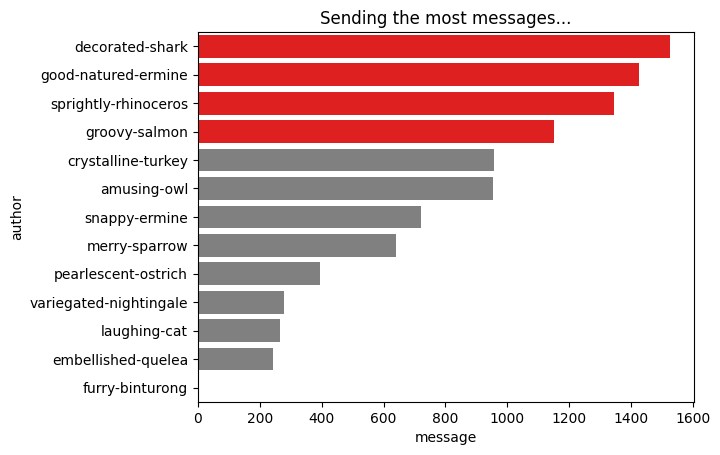

In [76]:
colors = [0 if x < 1000 else 1 for x in topk.message]
custom_palette = {0: "grey", 1: "red"}
sns.barplot(
    y=p1.index[:k],
    x="message",
    hue=colors,
    data=topk,
    palette=custom_palette,
    legend=False,
)
plt.title("Sending the most messages...")

Let's calculate the average message length.

Text(0.5, 1.0, 'Sending the longest messages...')

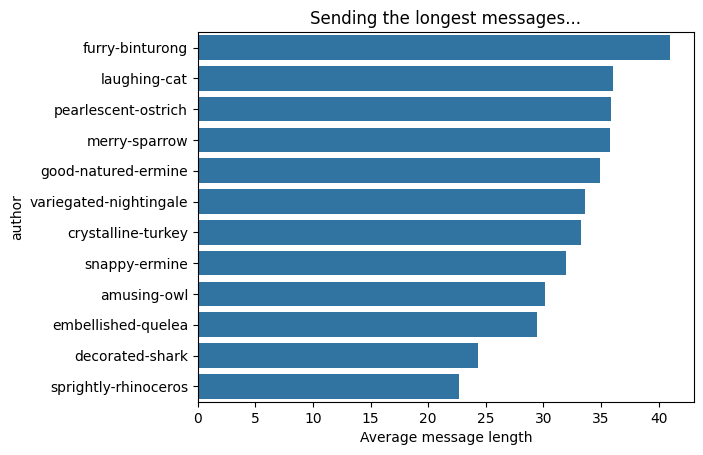

In [77]:
df["message_length"] = df["message"].str.len()
p1 = (
    df[["author", "message_length"]]
    .groupby("author")
    .mean()
    .sort_values("message_length", ascending=False)
)
k = 15
topk = p1[1:k]
sns.barplot(y=p1.index[1:k], x="message_length", data=topk)
plt.xlabel("Average message length")
plt.title("Sending the longest messages...")

Create a simple regex to look for links in the messages and add that as a feature:

Text(0.5, 1.0, 'Most links by...')

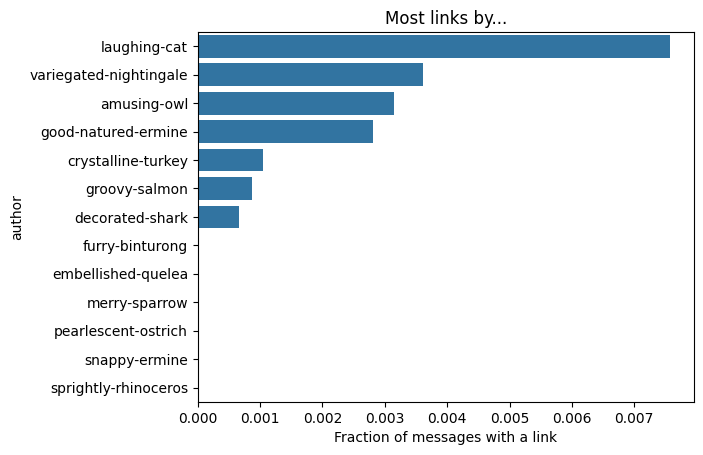

In [78]:
has_link = r"http"
df["has_link"] = df["message"].str.contains(has_link)
p1 = (
    df[["author", "has_link"]]
    .groupby("author")
    .mean()
    .sort_values("has_link", ascending=False)
)

k = 15
topk = p1[:k]
sns.barplot(y=p1.index[:k], x="has_link", data=topk)
plt.xlabel("Fraction of messages with a link")
plt.title("Most links by...")

Aggregate the emojis per user (can you change between sum and mean?)

Text(0.5, 1.0, "Are emoji's non-verbal?")

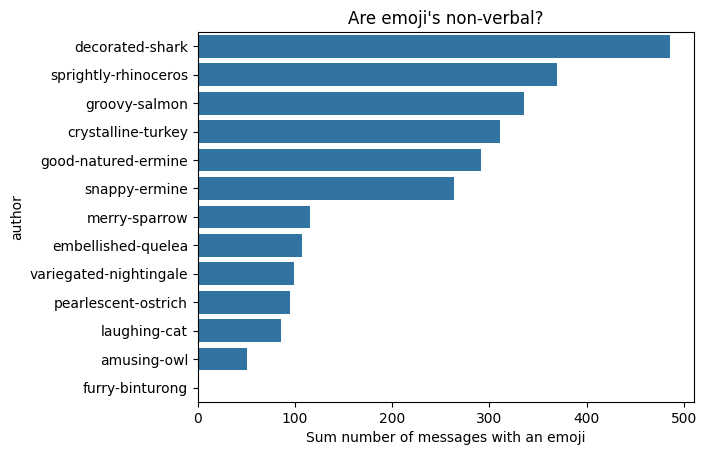

In [79]:
p2 = (
    df[["author", "has_emoji"]]
    .groupby("author")
    .agg(["sum", "mean"])
    .sort_values(("has_emoji", "sum"), ascending=False)
)

p2.columns = p2.columns.droplevel(0)
topk = p2[:k]
sns.barplot(y=p2.index[:k], x="sum", data=topk)
plt.xlabel("Sum number of messages with an emoji")
plt.title("Are emoji's non-verbal?")

Let's add a cateory, based on the time when authors send a message:

In [80]:
import pandas as pd

# Define the time ranges
time_ranges = ["00:00", "06:00", "08:00", "17:30", "22:00", "23:59"]
# Define the category labels
categories = ["night", "morning", "worktimes", "evening", "late"]
# Categorize the timestamp column
df["timestamp_category"] = pd.cut(
    df["timestamp"].dt.time.astype(str),
    bins=time_ranges,
    labels=categories,
    right=False,
)
# Display the updated dataframe
df

,timestamp,message,author,has_emoji,is_topk,message_length,has_link,timestamp_category,hour,day_of_week
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,False,True,39,False,worktimes,10:14:17,5
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,False,True,41,False,evening,19:50:13,2
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,False,True,29,False,evening,19:59:39,2
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,False,True,18,False,evening,20:00:35,2
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,True,True,21,False,evening,20:07:02,2
...,...,...,...,...,...,...,...,...,...,...
9893,2025-03-16 17:16:14,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",crystalline-turkey,True,True,62,False,worktimes,17:16:14,6
9894,2025-03-16 22:33:05,"Wij zijn weer in Nederland, net de wieltjes w...",crystalline-turkey,False,True,62,False,late,22:33:05,6
9895,2025-03-17 07:24:32,Welcome back! 💪🏻\n,groovy-salmon,True,True,18,False,morning,07:24:32,0
9896,2025-03-17 15:14:03,‎ ‎afbeelding weggelaten\n,good-natured-ermine,False,True,25,False,worktimes,15:14:03,0


Now we can group and count the categories:

In [81]:
# Group the dataframe by 'author' and 'timestamp_category', and count the occurrences
p3 = df.groupby(["author", "timestamp_category"]).size().unstack()

# Calculate the fraction of each category for every author
p3_frac = p3.div(p3.sum(axis=1), axis=0)
p3_frac

timestamp_category,night,morning,worktimes,evening,late
author,,,,,
amusing-owl,0.032597,0.000000,0.601472,0.254469,0.111462
crystalline-turkey,0.029228,0.039666,0.615866,0.272443,0.042797
decorated-shark,0.017693,0.043250,0.568152,0.303408,0.067497
embellished-quelea,0.028807,0.016461,0.572016,0.329218,0.053498
furry-binturong,0.000000,0.000000,0.000000,1.000000,0.000000
good-natured-ermine,0.005614,0.028772,0.600702,0.308772,0.056140
groovy-salmon,0.011304,0.033043,0.615652,0.263478,0.076522
laughing-cat,0.015152,0.064394,0.685606,0.208333,0.026515
merry-sparrow,0.014085,0.023474,0.532081,0.311424,0.118936


Let's use plotly the create a stacked bar chart:

In [82]:
p4 = p3_frac.reset_index().melt(id_vars="author")
p4.head()

,author,timestamp_category,value
0,amusing-owl,night,0.032597
1,crystalline-turkey,night,0.029228
2,decorated-shark,night,0.017693
3,embellished-quelea,night,0.028807
4,furry-binturong,night,0.000000


In [83]:
p4_filtered = p4[p4["author"].isin(topk_authors)]

In [84]:
import plotly.express as px

fig = px.bar(
    p4_filtered, y="author", x="value", color="timestamp_category", barmode="stack"
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Let's extract the minimum and maximum time of the messages for every author, and convert that to a decimal fraction:

In [ ]:
df["hour"] = df["timestamp"].dt.time
summary_df = df.groupby("author")["hour"].agg(["min", "max"]).reset_index()


def convert_to_decimal_hours(timestamp):
    dec_hour = timestamp.hour + timestamp.minute / 60 + timestamp.second / 3600
    return dec_hour


summary_df["min_x_values"] = summary_df["min"].apply(convert_to_decimal_hours)
summary_df["max_x_values"] = summary_df["max"].apply(convert_to_decimal_hours)

# Drop the original 'min' and 'max' columns as they are no longer needed
summary_df = summary_df.drop(["min", "max"], axis=1)
summary_df

,author,min_x_values,max_x_values
0,amusing-owl,0.008889,23.991667
1,crystalline-turkey,0.017500,23.745000
2,decorated-shark,0.122778,23.935000
3,embellished-quelea,1.845556,23.423333
4,furry-binturong,19.836944,19.836944
5,good-natured-ermine,0.525833,23.998611
6,groovy-salmon,0.009444,23.690833
7,laughing-cat,0.070833,23.603056
8,merry-sparrow,0.581389,23.840278
9,pearlescent-ostrich,0.059722,23.959722


With this, we can create a nice barbell chart. Try to add colors for your own chart!

In [ ]:
summary_df.loc[summary_df["author"] == "laughing-cat"]

,author,min_x_values,max_x_values
7,laughing-cat,0.070833,23.603056


In [ ]:
# add colomn for color
summary_df["color"] = ["grey" if summary_df.loc[i]["author"] != "laughing-cat" else "red" for i in summary_df.index]

summary_df

,author,min_x_values,max_x_values,color
0,amusing-owl,0.008889,23.991667,grey
1,crystalline-turkey,0.017500,23.745000,grey
2,decorated-shark,0.122778,23.935000,grey
3,embellished-quelea,1.845556,23.423333,grey
4,furry-binturong,19.836944,19.836944,grey
5,good-natured-ermine,0.525833,23.998611,grey
6,groovy-salmon,0.009444,23.690833,grey
7,laughing-cat,0.070833,23.603056,red
8,merry-sparrow,0.581389,23.840278,grey
9,pearlescent-ostrich,0.059722,23.959722,grey


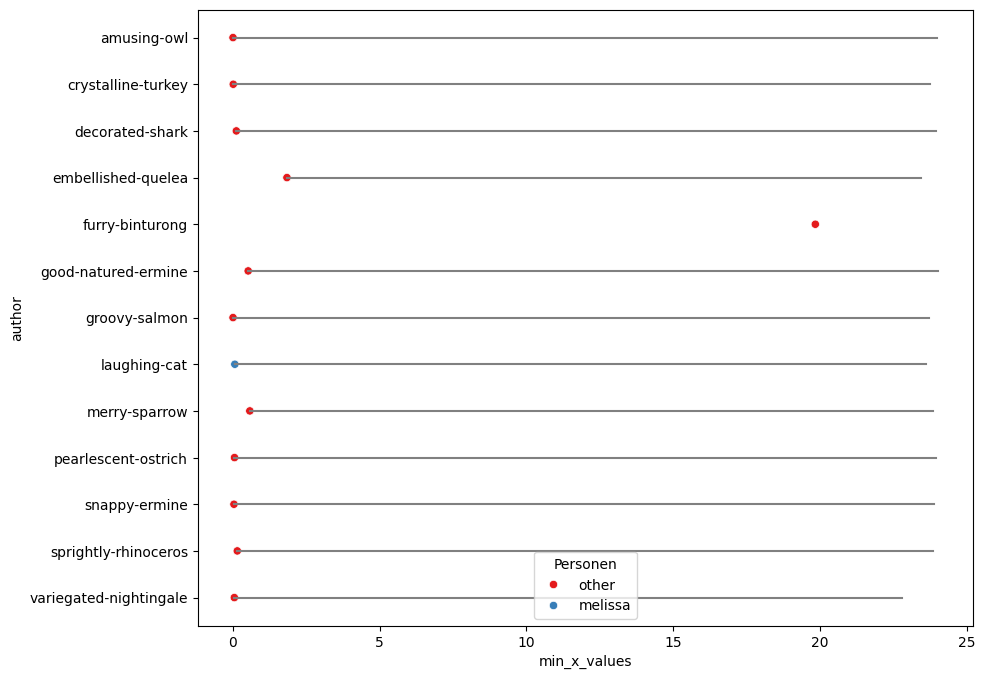

In [ ]:
# Create a larger plot
plt.figure(figsize=(10, 8))

# Create scatter plots
scatter = sns.scatterplot(data=summary_df, x="min_x_values", y="author", hue="color", palette="Set1")

# Add lines
for index, row in summary_df.iterrows():
    plt.plot(
        [row["min_x_values"], row["max_x_values"]],
        [row["author"], row["author"]],
        color="grey",
    )


# Adjust the font size of the y-axis labels if needed
plt.yticks(fontsize=10)

handles, labels = scatter.get_legend_handles_labels()
labels

# Maak een mapping van oude labels naar nieuwe labels
label_mapping = {"red": "melissa", "grey": "other"}

# Vervang de labels door de nieuwe namen
new_labels = [label_mapping[label] for label in labels]

# Pas de legenda aan met de nieuwe labels
plt.legend(handles, new_labels, title="Personen")

# Show the plot
plt.show()

Another approach for comparing is to create a heatmap:

Text(0.5, 1.0, 'Heatmap')

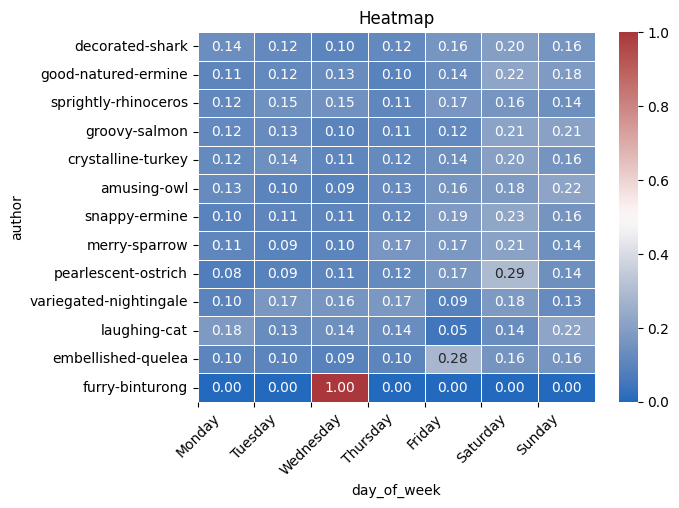

In [ ]:
df["day_of_week"] = df["timestamp"].dt.dayofweek
author_day_counts = df.groupby(["author", "day_of_week"]).size().unstack(fill_value=0)
author_day_percentages = author_day_counts.div(author_day_counts.sum(axis=1), axis=0)


filtered = author_day_percentages.loc[topk_authors]
sns.heatmap(filtered, annot=True, fmt=".2f", linewidths=0.5, cmap="vlag")
plt.xticks(
    ticks=range(7),
    labels=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
    rotation=45,
)
plt.title("Heatmap")

Let's save all the new features we added:

In [ ]:
datafile

PosixPath('/home/azureuser/MADS-DAV-MEL/data/processed/whatsapp-20250318-185053.parq')

In [ ]:
df.to_parquet(datafile, index=False)